# 02 按文本检索图像（CLIP + FAISS）

**目标**：输入一句文本（如「a photo of a dog」），从图库中检索出与文本最相似的 top-k 张图像。流程：用 CLIP 提取所有图像的嵌入 → 存入 FAISS 索引 → 用 CLIP 提取查询文本的嵌入 → 在 FAISS 中做最近邻搜索。

**步骤**：1 安装依赖 2 安装 FAISS 3 加载 CLIP 4 加载 CIFAR10 并限制 1000 张 5 提取图像特征并建 FAISS 索引 6 用提示检索并可视化结果。

## 1. 安装依赖
需要：transformers、torch、datasets；下一节安装 FAISS。

## 2. 安装 FAISS（支持 GPU 或 CPU）
仅 CPU 时安装 faiss-cpu。
使用 GPU 时安装 faiss-gpu。
根据硬件取消下方对应行的注释并运行。

In [1]:
#pip install faiss-gpu
#pip install faiss-cpu

## 3. 加载主干项目模型（best.pt）
使用本仓库训练得到的模型（256 维投影）；图像特征存 FAISS，查询时用文本特征在 FAISS 中搜索。

In [2]:
# 导入依赖并挂载主干项目
import sys
from pathlib import Path
import numpy as np
import torch
from PIL import Image
from transformers import CLIPTokenizer
from datasets import load_dataset, load_from_disk
import faiss
from tqdm import tqdm

ROOT = Path("/root/CLIP_26_ylslch")
if not (ROOT / "config.py").exists():
    ROOT = Path.cwd().resolve()
    while ROOT != ROOT.parent and not (ROOT / "config.py").exists():
        ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import config as CFG
from dataset import get_transforms
from models import CLIPModel as ProjectCLIPModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = CLIPTokenizer.from_pretrained(CFG.clip_local_dir or CFG.text_tokenizer)
transforms = get_transforms(mode="valid")
model = ProjectCLIPModel().to(device)
model.load_state_dict(torch.load(ROOT / "best.pt", map_location=device))
model.eval()

def pil_to_tensor(pil_img):
    img_np = np.array(pil_img)
    if len(img_np.shape) == 2:
        img_np = np.stack([img_np] * 3, axis=-1)
    out = transforms(image=img_np)["image"]
    return torch.tensor(out).permute(2, 0, 1).float().unsqueeze(0)

/root/miniconda3/envs/ylslch/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 198/198 [00:00<00:00, 731.10it/s, Materializing param=layernorm.weight]                                 
ViTModel LOAD REPORT from: /root/CLIP_26_ylslch/checkpoint/google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|██████████| 196/196 [00:0

## 4. 加载 CIFAR10 数据集
该数据集较小。本演示仅保留训练集并限制为 1000 张图像。

Dataset({
    features: ['img', 'label'],
    num_rows: 1000
})


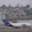

In [3]:
# 加载 CIFAR10 数据集（使用本地 dataset/cifar10，避免在线下载）
dataset = load_from_disk(str(ROOT / "dataset" / "cifar10"))

# 限制为 1000 张图像
from datasets import Dataset
subset_size = min(1000, len(dataset["train"]))
train_dataset = dataset["train"].select(range(subset_size))
print(train_dataset)

# 展示一张图像
display(train_dataset[0]['img'])

## 5. 提取图像特征并构建 FAISS 索引
- **extract_features_clip(image)**：用主干项目模型提取单张图像的 256 维特征。
- **add_vector_to_index(embedding, index)**：将嵌入转为 float32、L2 归一化后加入 FAISS 索引（IndexFlatL2 即暴力 L2 最近邻）。
遍历 1000 张图，逐张提取特征并写入 index。

In [4]:
import torch.nn.functional as F

# 将向量加入 FAISS 索引
def add_vector_to_index(embedding, index):
    # 将嵌入转为 numpy
    vector = embedding.detach().cpu().numpy()
    # 转为 float32 numpy
    vector = np.float32(vector)
    # 归一化向量（重要）
    faiss.normalize_L2(vector)
    # 加入索引
    index.add(vector)

# 提取给定图像的特征
def extract_features_clip(image):
    with torch.no_grad():
        x = pil_to_tensor(image).to(device)
        feat = model.image_projection(model.image_encoder(x))
        return F.normalize(feat, p=2, dim=-1)

# FAISS 索引：256 维（与主干模型投影维度一致）
index = faiss.IndexFlatL2(256)

for image in tqdm(train_dataset):
    clip_features = extract_features_clip(image["img"])
    add_vector_to_index(clip_features, index)
    
# 将索引写入本地，便于后续检索复用
faiss.write_index(index,"clip.index")

100%|██████████| 1000/1000 [00:06<00:00, 160.52it/s]


## 6. 用文本提示检索 top-k 图像
步骤：1）用 tokenizer + 主干模型 text_encoder + text_projection 得到查询文本的 256 维向量（已 L2 归一化）；2）转为 float32；3）index.search(text_np, k) 得到 L2 距离与对应的图像下标。distances 越小表示越相似。

In [5]:
# 示例：检索「狗」相关图像
prompt = "a photo of a dog"
enc = tokenizer([prompt], padding=True, truncation=True, max_length=CFG.max_length, return_tensors="pt")
enc = {k: v.to(device) for k, v in enc.items()}
with torch.no_grad():
    text_feat = model.text_encoder(input_ids=enc["input_ids"], attention_mask=enc.get("attention_mask"))
    text_emb = F.normalize(model.text_projection(text_feat), p=2, dim=-1)
text_np = text_emb.cpu().numpy().astype(np.float32)
faiss.normalize_L2(text_np)

k = 5
distances, indices = index.search(text_np, k)
print("L2 距离:", distances)
print("图像下标:", indices)

L2 距离: [[1.29446   1.305555  1.3124809 1.316816  1.3554939]]
图像下标: [[763  85 766 819 129]]


### 检索结果可视化
将 top-k 检索到的图像与相似度分数画在一张图中：L2 距离越小越相似，这里用 1/(1+d) 转为 0~1 的相似度便于阅读。

/tmp/ipykernel_2253/2399351574.py:13: UserWarning: Glyph 26816 (\N{CJK UNIFIED IDEOGRAPH-68C0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2253/2399351574.py:13: UserWarning: Glyph 32034 (\N{CJK UNIFIED IDEOGRAPH-7D22}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2253/2399351574.py:13: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2253/2399351574.py:13: UserWarning: Glyph 24352 (\N{CJK UNIFIED IDEOGRAPH-5F20}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/root/miniconda3/envs/ylslch/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26816 (\N{CJK UNIFIED IDEOGRAPH-68C0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/miniconda3/envs/ylslch/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32034 (\N{CJK UNIFIED IDEOGRAPH-7D22}) missing from font(s) Dej

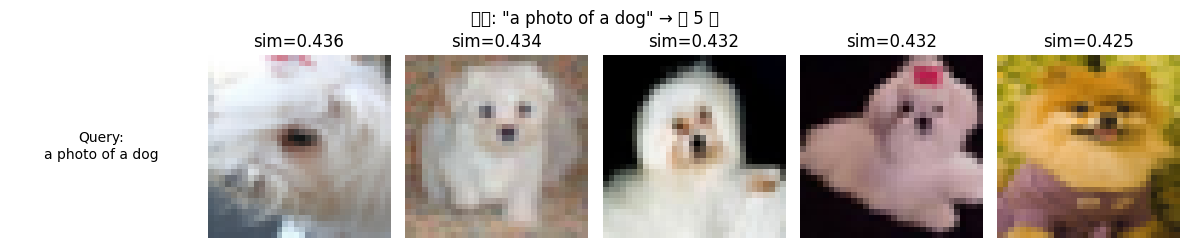

In [6]:
# 在一张图中展示：查询文本 + top-k 图像及相似度
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, k + 1, figsize=(2 * (k + 1), 2.5))
axes[0].text(0.5, 0.5, f'Query:\n{prompt}', ha='center', va='center', fontsize=10, wrap=True)
axes[0].axis('off')
for i, idx in enumerate(indices[0]):
    sim = 1 / (1 + distances[0][i])  # 0~1 相似度
    axes[i + 1].imshow(train_dataset[int(idx)]['img'])
    axes[i + 1].set_title(f'sim={sim:.3f}')
    axes[i + 1].axis('off')
plt.suptitle(f'检索: "{prompt}" → 前 {k} 张', fontsize=12)
plt.tight_layout()
plt.show()